In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
from tqdm.auto import tqdm


/Users/sepilovstepansergeevic/.pyenv/versions/3.13.11/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class Policy(nn.Module):
    def __init__(self, state_dim: int, actions_dim: int, hidden_size_dim: int = 64, use_gelu: bool = False):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_size),
            nn.GELU() if use_gelu else nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.GELU() if use_gelu else nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.GELU() if use_gelu else nn.ReLU(),
            nn.Linear(hidden_size, actions_dim) # return logits
        )

    def forward(self, state_vector):
        logits = self.net(state_vector)
        return torch.softmax(logits, dim=-1) # sum up to 1 across the rows

In [3]:
class ValueNet(nn.Module):
    def __init__(self, state_dim: int, hidden_dim: int = 64, use_gelu: bool = False):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.GELU() if use_gelu else nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU() if use_gelu else nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU() if use_gelu else nn.ReLU(),
            nn.Linear(hidden_dim, 1) # return value of state
        )

    def forward(self, state_vector):
        out = self.net(state_vector)
        return out

In [4]:
env = gym.make("CartPole-v1")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

In [5]:
hidden_size=64
use_gelu = True
num_episodes = 5_00
lr=1e-3
gamma = 0.995
v_lr = 1e-3

In [6]:
policy = Policy(state_dim, action_dim, hidden_size, use_gelu)

In [7]:
value_net = ValueNet(state_dim, hidden_size, use_gelu)

In [8]:
optimizer = optim.Adam(policy.parameters(), lr=lr)
optimizer_v = optim.Adam(value_net.parameters(), lr=v_lr)

In [9]:
episodic_rewards = []

for episode in tqdm(range(num_episodes), desc="Training"):
    state, info = env.reset()
    done = False

    buffer = []
    episode_reward = 0.0

    # Collect trajectory
    while not done:
        state_tensor = torch.as_tensor(state, dtype=torch.float32)

        # observe state -> take action -> get reward from environment
        logits = policy(state_tensor)
        distribution = Categorical(logits=logits)

        action = distribution.sample()
        log_prob = distribution.log_prob(action)

        next_state, reward, terminated, truncated, _ = env.step(action.item())

        # baseline net
        baseline = value_net(state_tensor)

        done = terminated or truncated

        buffer.append((log_prob, reward, baseline))

        episode_reward += reward
        state = next_state

    episodic_rewards.append(episode_reward)

    # policy update
    G = 0.0
    returns = []
    for _, reward, _ in reversed(buffer):
        G = reward + gamma * G
        returns.append(G)
        
    returns.reverse()
    returns = torch.tensor(returns, dtype=torch.float32)

    loss = 0.0
    for (log_prob, _, baseline), G in zip(buffer, returns):
        loss += -(G - baseline.detach())*log_prob

    # normalize loss by episode length
    loss /= len(buffer)
    
    # Policy gradient update
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


    # value net tuning
    values = torch.stack(
        [baseline for _, _, baseline in buffer],
        dim=0
    )

    value_loss = ((values - returns)**2).mean()

    optimizer_v.zero_grad()
    value_loss.backward()
    optimizer_v.step()

Training: 100%|██████████| 500/500 [00:10<00:00, 48.41it/s] 


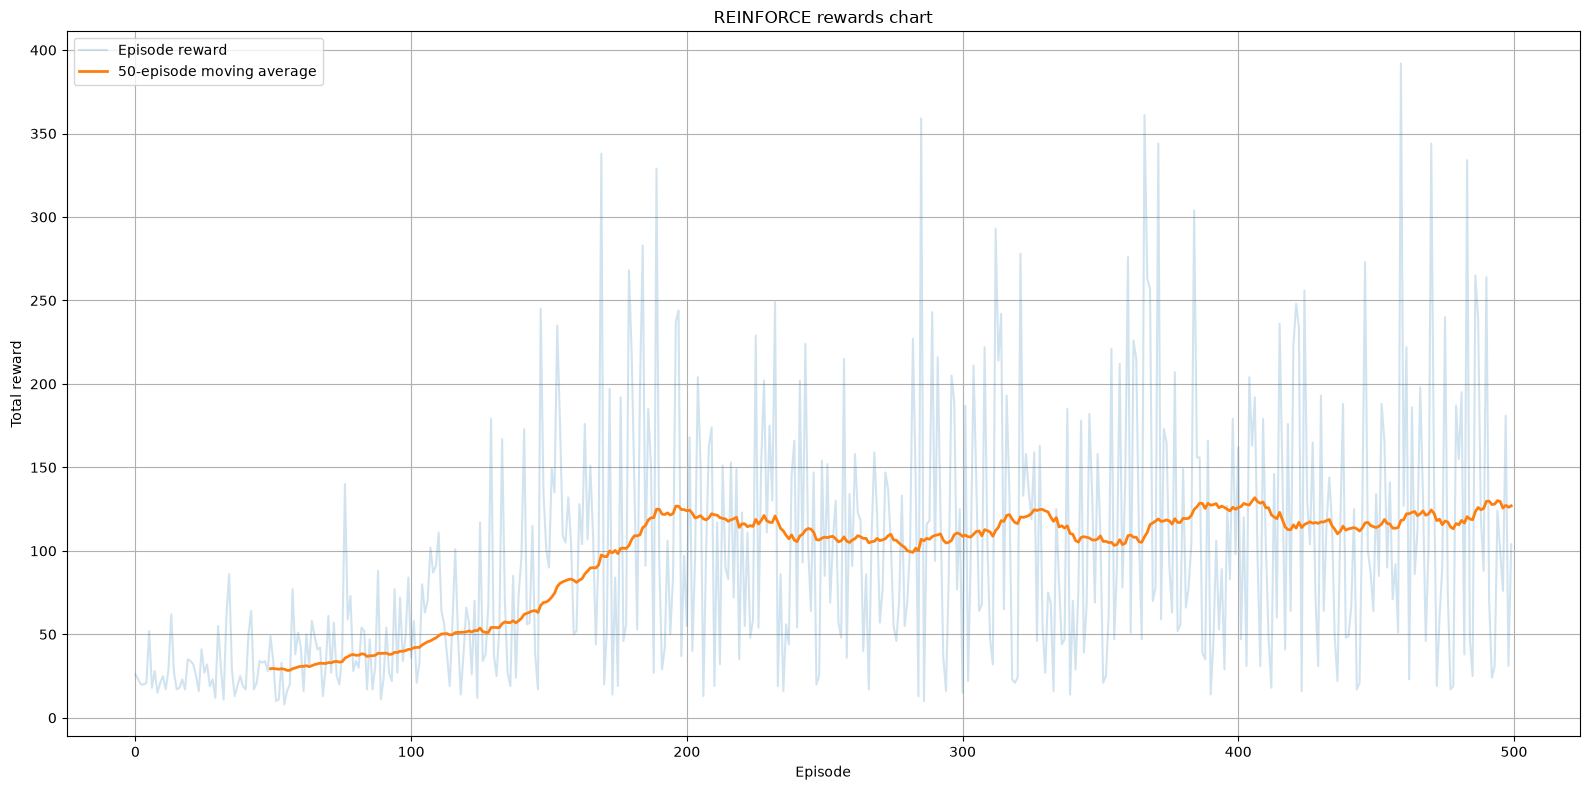

In [10]:
rewards = pd.Series(episodic_rewards)

plt.figure(figsize=(16, 8))

sns.lineplot(
    x=rewards.index,
    y=rewards,
    alpha=0.2,
    label="Episode reward",
)

sns.lineplot(
    x=rewards.index,
    y=rewards.rolling(50).mean(),
    linewidth=2,
    label="50-episode moving average",
)

plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.title("REINFORCE rewards chart")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()